E-Commerce Data Analysis

Data Consolidation 

Import the necessary libraries.

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

Load data from the excel file and inspect the data.

In [55]:
raw_df = pd.read_excel('data/gamezone-orders-data.xlsx')
df = raw_df.copy()

In [56]:
df.shape
df.columns
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21864 entries, 0 to 21863
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   USER_ID                  21864 non-null  object        
 1   ORDER_ID                 21864 non-null  object        
 2   PURCHASE_TS              21864 non-null  object        
 3   SHIP_TS                  21864 non-null  datetime64[ns]
 4   PRODUCT_NAME             21864 non-null  object        
 5   PRODUCT_ID               21864 non-null  object        
 6   USD_PRICE                21859 non-null  float64       
 7   PURCHASE_PLATFORM        21864 non-null  object        
 8   MARKETING_CHANNEL        21781 non-null  object        
 9   ACCOUNT_CREATION_METHOD  21781 non-null  object        
 10  COUNTRY_CODE             21826 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(9)
memory usage: 1.8+ MB


,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE
0,2c06175e,0001328c3c220830,2020-12-24 00:00:00,2020-12-13,Nintendo Switch,e682,168.00,website,affiliate,unknown,US
1,ee8e5bc2,0002af7a5c6100772,2020-10-01 00:00:00,2020-09-21,Nintendo Switch,e682,160.61,website,direct,desktop,DE
2,9eb4efe0,0002b8350e167074,2020-04-21 00:00:00,2020-02-16,Nintendo Switch,8d0d,151.20,website,direct,desktop,US
3,cac7cbaf,0006d06b98385729,2020-04-07 00:00:00,2020-04-04,Sony PlayStation 5 Bundle,54ed,1132.82,website,direct,desktop,AU
4,6b0230bc,00097279a2f46150,2020-11-24 00:00:00,2020-08-02,Nintendo Switch,8d0d,33.89,website,direct,desktop,TR


Data Cleaning

Exact duplicate rows were identified and removed. 

In [57]:
# df.duplicated().sum()
df = df.drop_duplicates()

Duplicates based on the 'ORDER_ID' column were also dropped. 

In [58]:
df['ORDER_ID'].duplicated().sum()
df[df['ORDER_ID'].duplicated(keep=False)][['ORDER_ID', 'ACCOUNT_CREATION_METHOD', 'USD_PRICE']]
df = df.drop_duplicates(subset='ORDER_ID')

After identifying the missing data, I dropped the rows that had null values in either the 'USD_PRICE' or 'COUNTRY_CODE' columns. 

I then filled the missing values in the 'MARKETING_CHANNEL' & 'ACCOUNT_CREATION_METHOD' rows with 'unknown'.


In [59]:
# print(df.isna().sum())
df = df.dropna(subset=['USD_PRICE', 'COUNTRY_CODE'])
df = df.fillna('unknown')

Extreme outliers were omitted. A histogram was used to understand the skew. 

In [60]:
Q1 = df['USD_PRICE'].quantile(0.25)
Q3 = df['USD_PRICE'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

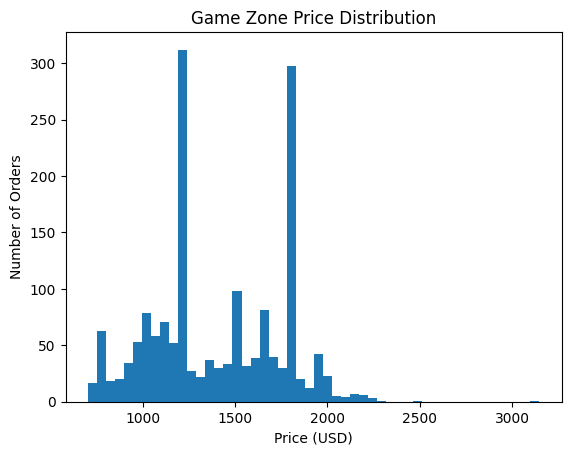

In [61]:
df2 = df[df['USD_PRICE'] > upper]
x = df2['USD_PRICE'].value_counts().sort_index()
plt.hist(df2['USD_PRICE'], bins=50)
plt.xlabel("Price (USD)")
plt.title("Game Zone Price Distribution")
plt.ylabel("Number of Orders")
plt.show()

In [62]:
df = df[(df['USD_PRICE'] >= lower) & (df['USD_PRICE'] <= upper)]

Corrected the Data Type for the 'PURCHASE_TS' column.

Timestamp fields were converted to datetime format to enable time-based analysis.
Rows with missing purchase timestamps were removed, as time-based analysis required valid transaction dates.

In [63]:
df['PURCHASE_TS'] = pd.to_datetime(df['PURCHASE_TS'], errors='coerce')
df = df.dropna(subset=['PURCHASE_TS'])

Created a cleaned copy of the dataframe.

In [64]:
clean_df = df.copy()

Overview of the cleaned dataset.

In [65]:
clean_data_overview = pd.DataFrame({
    "metric":[
        "rows",
        "duplicate_orders",
        "null_price",
        "null_purchase_ts",
        "unknown_marketing_channel"
    ],

    "value": [
        clean_df.shape[0],
        clean_df['ORDER_ID'].duplicated().sum(),
        clean_df['USD_PRICE'].isna().sum(),
        clean_df['PURCHASE_TS'].isna().sum(),
        (clean_df['MARKETING_CHANNEL'] == 'unknown').sum()
    ]
})

print(clean_data_overview)

                      metric  value
0                       rows  20002
1           duplicate_orders      0
2                 null_price      0
3           null_purchase_ts      0
4  unknown_marketing_channel    115


Analysis of Cleaned Data

KPI Metrics

In [66]:
kpis = pd.DataFrame({
    "metric": [
        "Total Orders",
        "Total Revenue (USD)",
        "Average Order Value (USD)",
        "Unique Customers",
        "Orders per Customer"
    ],
    "value": [
        clean_df['ORDER_ID'].nunique(),
        clean_df['USD_PRICE'].sum(),
        clean_df['USD_PRICE'].mean(),
        clean_df['USER_ID'].nunique(),
        clean_df['ORDER_ID'].nunique() / clean_df['USER_ID'].nunique()
    ]
})

kpis['value'] = kpis['value'].map('{:,.2f}'.format)

print(kpis)

                      metric         value
0               Total Orders     20,002.00
1        Total Revenue (USD)  3,757,721.51
2  Average Order Value (USD)        187.87
3           Unique Customers     18,246.00
4        Orders per Customer          1.10


Revenue trends over time

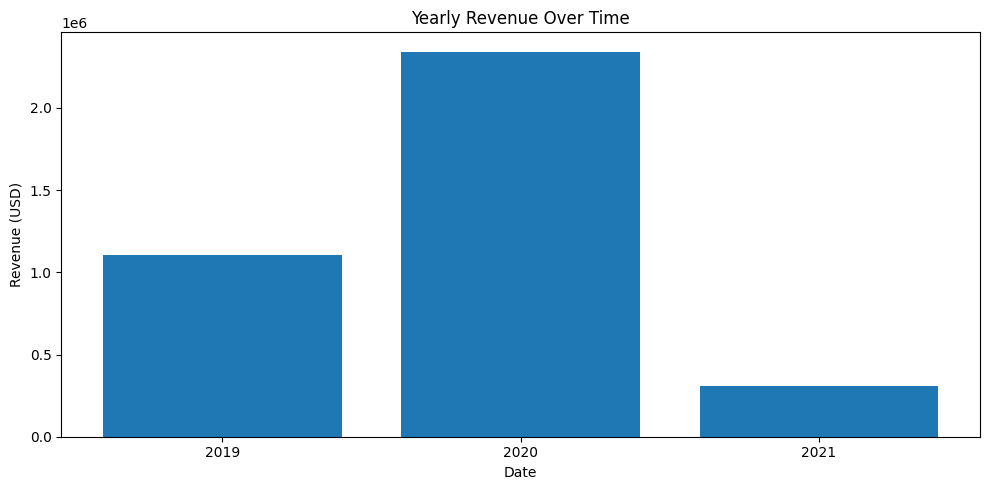

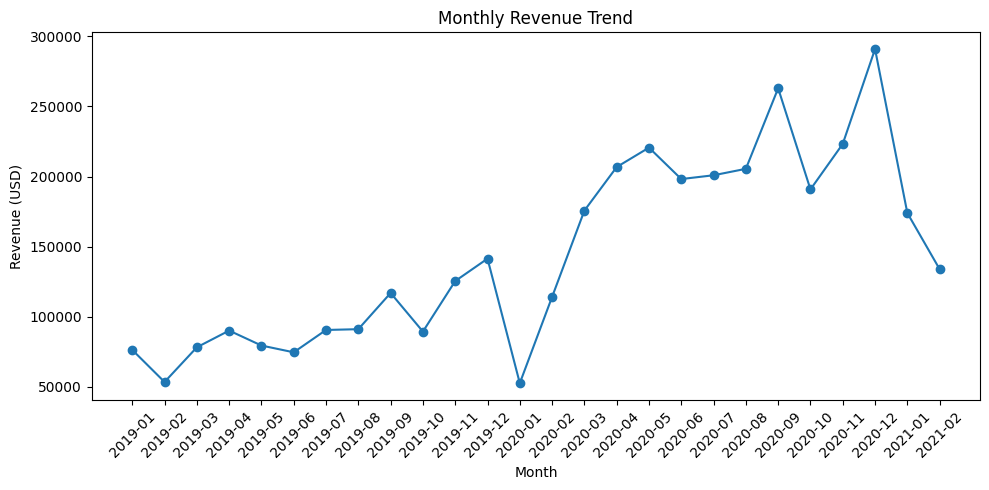

In [67]:
clean_df['purchase_date'] = clean_df['PURCHASE_TS'].dt.date
clean_df['purchase_month'] = clean_df['PURCHASE_TS'].dt.to_period('M')
clean_df['purchase_year'] = clean_df['PURCHASE_TS'].dt.to_period('Y')

yearly_revenue = (
    clean_df
    .groupby('purchase_year')['USD_PRICE']
    .sum()
    .reset_index()
)

yearly_revenue['purchase_year'] = yearly_revenue['purchase_year'].astype(str)
plt.figure(figsize=(10,5))
plt.bar(yearly_revenue['purchase_year'], yearly_revenue['USD_PRICE'])
plt.title("Yearly Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue (USD)")
plt.tight_layout()

plt.savefig("charts/yearly_revenue.png")

monthly_revenue = (
    clean_df
    .groupby('purchase_month')['USD_PRICE']
    .sum()
    .reset_index()
)

monthly_revenue['purchase_month'] = monthly_revenue['purchase_month'].astype(str)
plt.figure(figsize=(10,5))
plt.plot(monthly_revenue['purchase_month'], monthly_revenue['USD_PRICE'], marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/monthly_revenue.png")

Revenue exhibits an overall upward trend, indicating business growth over time. This statement takes into account the fact data for the year 2021 includes the months January and February only.

The pattern is highly volatile, with significant spikes concentrated in specific periods. This suggests that revenue growth is largely driven by intermittent events rather than sustained, predictable demand.

Channel Summary

In [68]:
channel_summary = (
    clean_df
    .groupby('MARKETING_CHANNEL')
    .agg(
        orders=('ORDER_ID', 'count'),
        revenue=('USD_PRICE', 'sum'),
        avg_order_value=('USD_PRICE', 'mean')
    )
    .sort_values('revenue', ascending=False)
)

print(channel_summary)


                   orders     revenue  avg_order_value
MARKETING_CHANNEL                                     
direct              15817  3080935.16       194.786316
email                3138   468458.57       149.285714
affiliate             622   134141.50       215.661576
social media          310    54704.26       176.465355
unknown               115    19482.02       169.408870


<Figure size 1200x600 with 0 Axes>

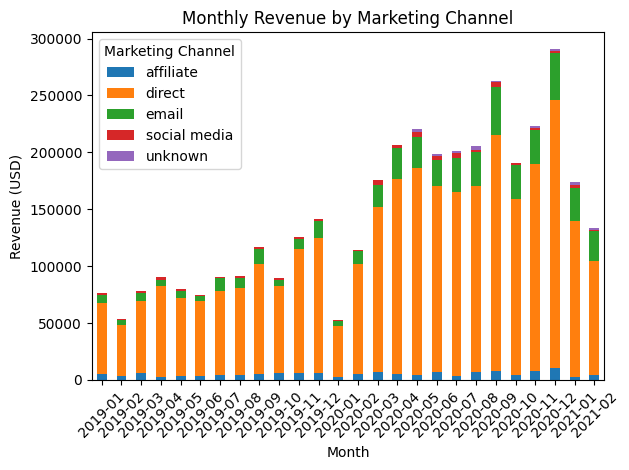

In [69]:
monthly_revenue_by_channel = (
    clean_df
    .groupby(['purchase_month', 'MARKETING_CHANNEL'])['USD_PRICE']
    .sum()
    .reset_index()
)

monthly_revenue_by_channel_pivot=(
    monthly_revenue_by_channel.pivot(
        index='purchase_month',
        columns='MARKETING_CHANNEL',
        values='USD_PRICE'
    )
    .fillna(0)
)

monthly_revenue_by_channel_pivot.index = (
    monthly_revenue_by_channel_pivot.index.astype(str)
)
plt.figure(figsize=(12,6))

monthly_revenue_by_channel_pivot.plot(
    kind='bar',
    stacked=True
)

plt.title("Monthly Revenue by Marketing Channel")
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)
plt.legend(
    title="Marketing Channel",
    loc="upper left"
)
plt.tight_layout()

plt.savefig("charts/monthly_revenue_by_channel.png")


Marketing performance varies significantly by channel. 

Revenue is concentrated among a subset of channels, while average order value differs substantially across acquisition sources, indicating varying customer intent. 

A meaningful share of orders is attributed to an ‘unknown’ channel, highlighting incomplete attribution and limiting full visibility into marketing effectiveness.